In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [5]:
pd.to_datetime("17:30").time()

datetime.time(17, 30)

In [6]:
if datetime.now(timezone.utc).time() >= pd.to_datetime("17:30").time():
    print("Stop the Trading Session!")

In [7]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, window, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = []

        #*****************add strategy-specific attributes here******************
        self.window = window
        #************************************************************************

    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break

    def on_success(self, time, bid, ask):

        print(self.ticks, end = " ")

        recent_tick = pd.to_datetime(time)

        # define stop
        if recent_tick.time() >= pd.to_datetime("13:00").time():
            self.stop_stream = True

        df = pd.DataFrame({self.instrument:(ask + bid)/2},
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()

        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()

    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length,
                                                                          label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]

    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()

        #******************** define your strategy here ************************
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        df["position"] = -np.sign(df.returns.rolling(self.window).mean())
        #***********************************************************************

        self.data = df.copy()

    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1:
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0:
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            self.position = 0

    def report_trade(self, order, going):
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print(f'{time} | {going}'
        print(f'{time} | units = {units} | price = {price} | P&L = {pl} | Cum P&L = {cumpl}'
        print(100 * "-" + "\n")


In [8]:
trader = ConTrader(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Trading\Data\oanda.cfg', "EUR_USD", "1min", window = 1, units = 100000)

In [9]:
trader.get_most_recent()
trader.stream_data(trader.instrument) # no stop after n ticks!
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units,
                                      suppress = True, ret = True)
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 
----------------------------------------------------------------------------------------------------
2025-12-12T10:02:00.565612591Z | GOING SHORT
2025-12-12T10:02:00.565612591Z | units = -100000.0 | price = 1.17311 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 
----------------------------------------------------------------------------------------------------
2025-12-12T10:03:00.483380897Z | GOING LONG
2025-12-12T10:03:00.483380897Z | units = 200000.0 | price = 1.17319 | P&L = -6.8534 | Cum P&L = -6.8534
----------------------------------------------------------------------------------------------------

V20Timeout: v20 REST request to https://stream-fxpractice.oanda.com:443/v3/accounts/101-011-37633556-002/pricing/stream?instruments=EUR_USD&snapshot=True has timed out (stream)

In [10]:
trader.data

,EUR_USD,returns,position
2025-12-07 22:05:00+00:00,1.164010,NaN,NaN
2025-12-07 22:06:00+00:00,1.164060,0.000043,-1.0
2025-12-07 22:07:00+00:00,1.164020,-0.000034,1.0
2025-12-07 22:08:00+00:00,1.164080,0.000052,-1.0
2025-12-07 22:09:00+00:00,1.164040,-0.000034,1.0
...,...,...,...
2025-12-12 10:09:00+00:00,1.173100,0.000017,-1.0
2025-12-12 10:10:00+00:00,1.173095,-0.000004,1.0
2025-12-12 10:11:00+00:00,1.173100,0.000004,-1.0
2025-12-12 10:12:00+00:00,1.173080,-0.000017,1.0


In [27]:
trader.data.['EUR_USD','returns'].plot(figsize = (12, 8))
plt.show()

SyntaxError: invalid syntax (695961654.py, line 1)

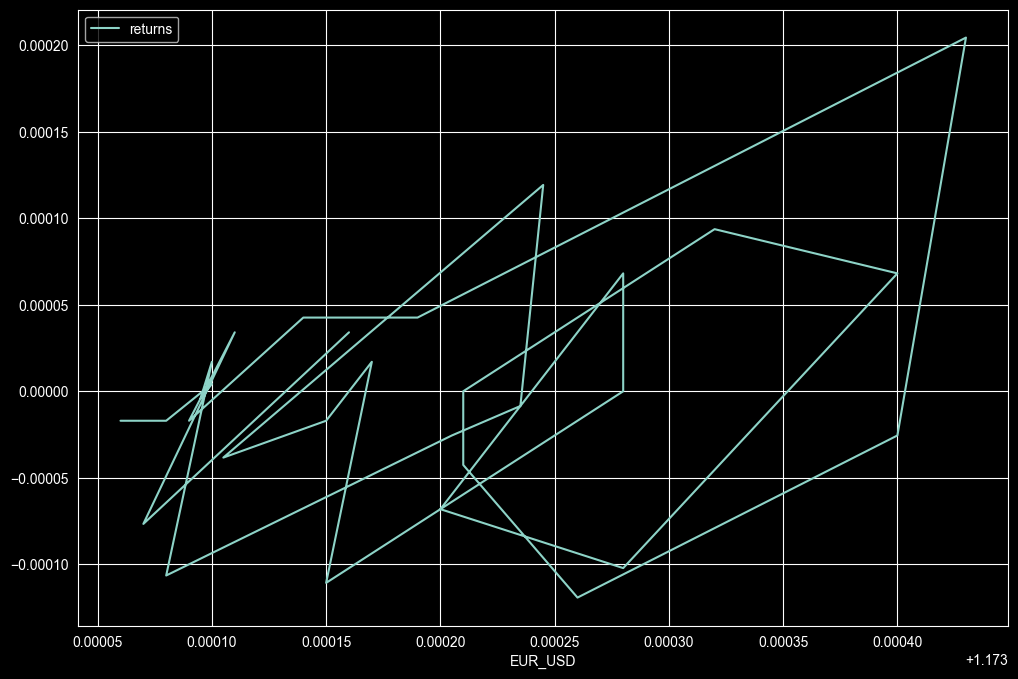

In [29]:
trader.data.tail(30).plot(x='EUR_USD', y='returns', figsize=(12, 8))  # Nur EUR_USD vs. Index
plt.show()